In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmedzayed30","key":"9377e753b6e995271b8c07341d7beda2"}'}

In [6]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!kaggle datasets download -d mirichoi0218/insurance --unzip

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 30.4MB/s]



In [7]:
import pandas as pd
data = pd.read_csv('/content/insurance.csv')
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
data.shape

(1338, 7)

In [11]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [12]:
data['charges'].describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


In [13]:
data.groupby('sex')['charges'].mean()

,charges
sex,
female,12569.578844
male,13956.751178


In [14]:
data.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


In [15]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'])
data.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [16]:
x = data.drop('charges', axis=1)
y = data['charges']

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [19]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [20]:
lr.score(x_test, y_test)

0.7835929767120722

In [21]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [22]:
rf.score(x_test, y_test)

0.8624125433327905

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(x_train, y_train)

GradientBoostingRegressor()

In [24]:
gb.score(x_test, y_test)

0.8793530602367607

In [25]:
from xgboost import XGBRegressor
xg = XGBRegressor()
xg.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
xg.score(x_test, y_test)

0.8553648660539922

In [27]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

Ridge()

In [28]:
ridge.score(x_test, y_test)

0.7835661821408255

In [29]:
gb = GradientBoostingRegressor(random_state=42)
params = {
    'n_estimators'== 600,
    'learning_rate'== 0.03,
    'max_depth'== 3,
    'subsample'== 0.8,
    'min_samples_split'== 5,
    'min_samples_leaf'== 2,
    'random_state'== 42
}
gb.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [30]:
gb.score(x_test, y_test)

0.8793364486536337

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = gb.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = gb.score(x_test, y_test)

print(f"R² Score:  {r2:.4f}")
print(f"MAE:       ${mae:,.2f}")
print(f"RMSE:      ${rmse:,.2f}")

R² Score:  0.8793
MAE:       $2,404.90
RMSE:      $4,328.15


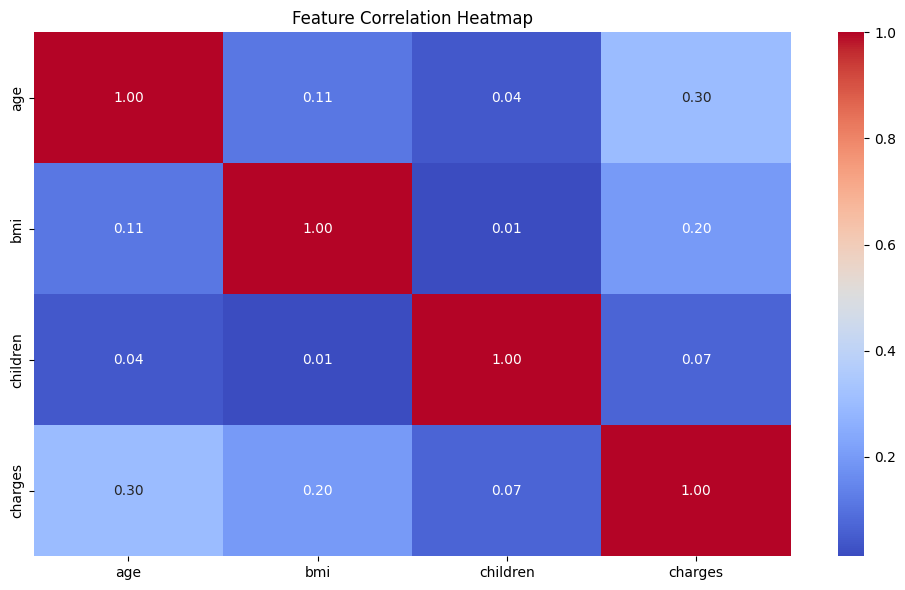

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_data = data.select_dtypes(include='number')
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

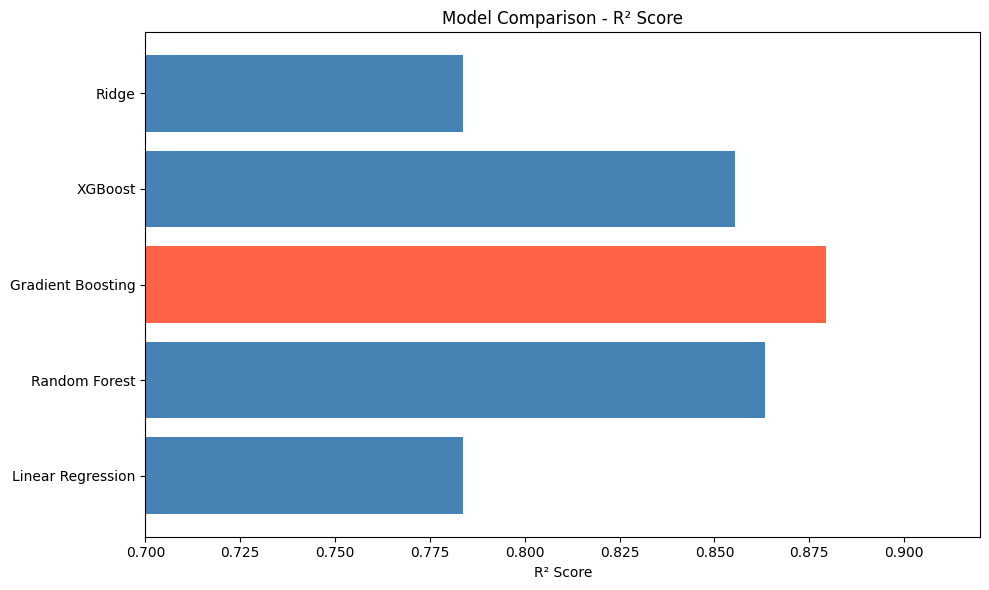

In [34]:
models = {
    'Linear Regression': 0.7836,
    'Random Forest': 0.8634,
    'Gradient Boosting': 0.8793,
    'XGBoost': 0.8554,
    'Ridge': 0.7836
}

plt.figure(figsize=(10, 6))
colors = ['tomato' if v == max(models.values()) else 'steelblue' for v in models.values()]
plt.barh(list(models.keys()), list(models.values()), color=colors)
plt.xlim(0.7, 0.92)
plt.title('Model Comparison - R² Score')
plt.xlabel('R² Score')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [36]:
import gradio as gr

def predict_insurance(age, bmi, children, sex, smoker, region):
    input_data = {
        'age': age, 'bmi': bmi, 'children': children,
        'sex_female': 1 if sex == 'female' else 0,
        'sex_male': 1 if sex == 'male' else 0,
        'smoker_no': 1 if smoker == 'no' else 0,
        'smoker_yes': 1 if smoker == 'yes' else 0,
        'region_northeast': 1 if region == 'northeast' else 0,
        'region_northwest': 1 if region == 'northwest' else 0,
        'region_southeast': 1 if region == 'southeast' else 0,
        'region_southwest': 1 if region == 'southwest' else 0,
    }
    df = pd.DataFrame([input_data]).reindex(columns=feature_columns, fill_value=0)
    df_scaled = sc.transform(df)
    prediction = gb.predict(df_scaled)[0]
    return f"💰 Estimated Insurance Cost: ${prediction:,.2f}"

gr.Interface(
    fn=predict_insurance,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="BMI"),
        gr.Number(label="Children"),
        gr.Radio(["male", "female"], label="Sex"),
        gr.Radio(["yes", "no"], label="Smoker"),
        gr.Radio(["northeast", "northwest", "southeast", "southwest"], label="Region")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🏥 Medical Insurance Cost Predictor",
    description="Enter patient details to predict insurance charges using Gradient Boosting model (R²: 0.8793)"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f2b0d251e3bc6af08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
